# Exploratory Data Analysis
## Iowa Quarterly Retail Sales Tax Data

This notebook performs an initial exploratory data analysis (EDA) on the Iowa Quarterly Retail Sales Tax dataset from https://data.iowa.gov/Taxes-Tax-Credits/Iowa-Quarterly-Retail-Sales-Tax-Data-by-12-Busines/wsde-3id9/about_data


The target audience includes business analysts and policymakers who are interested in understanding economic activity, identifying high-performing sectors in Iowa, and observing trends over time.

This analysis is useful because it highlights which industries and regions drive the most sales, how activity changes seasonally, and whether key variables such as sales and returns are strongly related.

## 1. Load the Data

Import pandas and read the CSV file into a DataFrame called retail_data.

In [75]:
import pandas as pd

retail_data = pd.read_csv('Iowa_Quarterly_Retail_Sales_Tax_Data_by_12_Business_Groups_20260413.csv')

## 2. DataFrame Info

Use .info() to inspect column names, data types, and non-null counts. This helps identify missing values and whether columns need type conversion.

In [76]:
retail_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 132586 entries, 0 to 132585
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   Fiscal Year        132586 non-null  int64
 1   Quarter Ending     132586 non-null  str  
 2   County Number      132586 non-null  int64
 3   County             132586 non-null  str  
 4   Business Group     132585 non-null  str  
 5   Number of Returns  119622 non-null  str  
 6   Taxable Sales      119646 non-null  str  
 7   Computed Tax       119646 non-null  str  
 8   Percent of Tax     119646 non-null  str  
 9   Suppressed         132586 non-null  bool 
dtypes: bool(1), int64(2), str(7)
memory usage: 9.2 MB


Here we see discrepancies between the # of fiscal year to County (all 132586) and the rest of the datapoints, so we know there is missing data. 

## 3. First 5 Rows

Use .head() to preview the first 5 rows and get a feel for the structure, column names, and raw values (note currency and percent formatting in some columns).

In [77]:
retail_data.head()

,Fiscal Year,Quarter Ending,County Number,County,Business Group,Number of Returns,Taxable Sales,Computed Tax,Percent of Tax,Suppressed
0,2023,Sep 2022,42,Hardin,Apparel,21,"$357,947","$21,477",0.00%,False
1,2023,Sep 2022,45,Howard,Service,205,"$4,437,987","$265,848",0.04%,False
2,2023,Sep 2022,54,Keokuk,Wholesale,34,"$1,818,165","$109,090",0.01%,False
3,2023,Sep 2022,86,Tama,Wholesale,49,"$4,806,898","$288,414",0.04%,False
4,2001,Dec 2000,55,Kossuth,Motor Vehicle,31,"$2,821,069","$141,053",0.04%,False


## 4. Random Sample of 25 Rows

Use .sample(25) to view a random selection of rows across the dataset, giving a broader sense of the data distribution beyond just the first few records.

In [78]:
retail_data.sample(25)

,Fiscal Year,Quarter Ending,County Number,County,Business Group,Number of Returns,Taxable Sales,Computed Tax,Percent of Tax,Suppressed
51966,2009,Sep 2008,26,Davis,Miscellaneous,53,"$2,089,824","$125,389",0.02%,False
100693,2018,Mar 2018,12,Butler,Utilities and Transportation,21,"$1,665,968","$99,958",0.02%,False
8881,2000,Mar 2000,83,Shelby,County Totals,534,"$16,879,777","$843,989",0.27%,False
83596,2015,Sep 2014,73,Page,Motor Vehicle,18,"$1,546,490","$92,789",0.02%,False
100779,2018,Mar 2018,19,Chickasaw,Home Furnishings,NaN,NaN,NaN,NaN,True
18188,2002,Mar 2002,7,Black Hawk,Motor Vehicle,120,"$13,231,883","$661,594",0.21%,False
59883,2010,Mar 2010,39,Guthrie,Food Dealers,11,"$1,783,078","$106,985",0.03%,False
121100,2022,Mar 2022,4,Appanoose,Eating and Drinking,22,"$2,270,492","$136,092",0.02%,False
24657,2003,Jun 2003,9,Bremer,Motor Vehicle,22,"$2,001,037","$100,052",0.03%,False
56147,2009,Jun 2009,51,Jefferson,Service,182,"$5,062,990","$298,379",0.06%,False


## Cleaning the Data

Seems like missing datapoints are just null instead of encoded placeholders. Moving forward I will remove these rows to clean the data.

In [79]:
# remove suppressed rows and aggregate rows (totals)
retail_data_cleaned = retail_data[
    (retail_data['Suppressed'] == False) &
    (~retail_data['Business Group'].isin(['County Totals', 'State Totals']))
].copy()

print(f"Original rows : {len(retail_data)}")

# drop rows with missing values in key columns
retail_data_cleaned = retail_data_cleaned.dropna(subset=[
    'Taxable Sales', 'Computed Tax', 'Percent of Tax', 'Number of Returns'
])

print(f"After NA removal : {len(retail_data_cleaned)}")

# clean numeric columns
retail_data_cleaned['Taxable Sales'] = retail_data_cleaned['Taxable Sales'].replace(r'[\$,]', '', regex=True).astype(float)
retail_data_cleaned['Computed Tax'] = retail_data_cleaned['Computed Tax'].replace(r'[\$,]', '', regex=True).astype(float)
retail_data_cleaned['Percent of Tax'] = retail_data_cleaned['Percent of Tax'].str.replace('%', '', regex=False).astype(float)
retail_data_cleaned['Number of Returns'] = retail_data_cleaned['Number of Returns'].replace(',', '', regex=True).astype(float)

print(f"Final cleaned rows : {len(retail_data_cleaned)}")
print(f"Total rows removed : {len(retail_data) - len(retail_data_cleaned)}")

# check result
retail_data_cleaned.info()
retail_data_cleaned.sample(25)

Original rows : 132586
After NA removal : 109392
Final cleaned rows : 109392
Total rows removed : 23194
<class 'pandas.DataFrame'>
Index: 109392 entries, 0 to 132583
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Fiscal Year        109392 non-null  int64  
 1   Quarter Ending     109392 non-null  str    
 2   County Number      109392 non-null  int64  
 3   County             109392 non-null  str    
 4   Business Group     109391 non-null  str    
 5   Number of Returns  109392 non-null  float64
 6   Taxable Sales      109392 non-null  float64
 7   Computed Tax       109392 non-null  float64
 8   Percent of Tax     109392 non-null  float64
 9   Suppressed         109392 non-null  bool   
dtypes: bool(1), float64(4), int64(2), str(3)
memory usage: 8.5 MB


,Fiscal Year,Quarter Ending,County Number,County,Business Group,Number of Returns,Taxable Sales,Computed Tax,Percent of Tax,Suppressed
71367,2012,Jun 2012,30,Dickinson,Apparel,14.0,745093.0,44706.0,0.01,False
75760,2013,Mar 2013,70,Muscatine,General Merchandise,25.0,18523054.0,1111383.0,0.24,False
8182,2000,Mar 2000,29,Des Moines,General Merchandise,24.0,23435451.0,1171773.0,0.38,False
93957,2017,Sep 2016,78,Pottawattamie,Utilities and Transportation,76.0,36485044.0,2189103.0,0.36,False
20663,2002,Jun 2002,98,Worth,Wholesale,17.0,891907.0,44595.0,0.01,False
36845,2006,Sep 2005,57,Linn,Home Furnishings,120.0,30333172.0,1516659.0,0.38,False
7508,2024,Dec 2023,76,Pocahontas,Motor Vehicle,15.0,221519.0,13291.0,0.00,False
19111,2002,Mar 2002,78,Pottawattamie,Motor Vehicle,72.0,9413025.0,470651.0,0.15,False
54294,2009,Mar 2009,7,Black Hawk,Wholesale,171.0,27818598.0,1665657.0,0.38,False
12214,2001,Dec 2000,42,Hardin,Eating and Drinking,41.0,2034731.0,101737.0,0.03,False


After cleaning, the dataset is significantly reduced in size, indicating that a substantial portion of the original data contained missing or suppressed values. This highlights the importance of data preprocessing before performing analysis.

In [80]:
summary_stats = retail_data_cleaned.describe()
summary_stats.round(3)

,Fiscal Year,County Number,Number of Returns,Taxable Sales,Computed Tax,Percent of Tax
count,109392.000,109392.000,109392.000,1.093920e+05,1.093920e+05,109392.000
mean,2012.756,50.232,93.654,8.629565e+06,4.932059e+05,0.094
std,7.493,28.520,350.663,4.003974e+07,2.364023e+06,0.392
min,2000.000,1.000,5.000,0.000000e+00,0.000000e+00,0.000
25%,2006.000,25.000,16.000,1.111411e+06,6.204700e+04,0.010
50%,2013.000,50.000,33.000,2.461928e+06,1.381905e+05,0.030
75%,2019.000,75.000,86.000,5.704042e+06,3.279542e+05,0.060
max,2026.000,100.000,80957.000,1.072494e+10,6.402090e+08,100.000


Checking correlation of some datapoints. makes sense that tax is correlated with tax...  

In [81]:
cols = ['Taxable Sales', 'Computed Tax', 'Percent of Tax', 'Number of Returns']

correlation_matrix = retail_data_cleaned[cols].corr()
correlation_matrix.round(5)

,Taxable Sales,Computed Tax,Percent of Tax,Number of Returns
Taxable Sales,1.00000,0.99898,0.98960,0.85319
Computed Tax,0.99898,1.00000,0.98392,0.85195
Percent of Tax,0.98960,0.98392,1.00000,0.83137
Number of Returns,0.85319,0.85195,0.83137,1.00000


Now I will investigate the outliers for each category

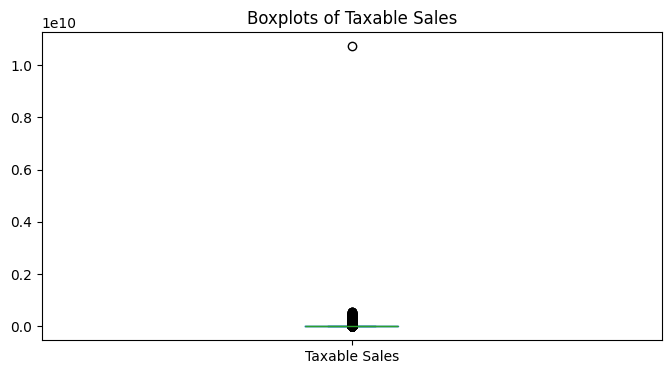

In [82]:
import matplotlib.pyplot as plt

cols = ['Taxable Sales']
retail_data_cleaned[cols].plot.box(figsize=(8,4))
plt.title('Boxplots of Taxable Sales')
plt.show()

The summary statistics show that taxable sales and computed tax are highly variable, with large differences between minimum and maximum values. This suggests a skewed distribution, likely driven by a small number of high-performing counties or industries.

## Quarter Analysis
Now I will start Investigations into correlations by quarter

In [83]:
cols = ['Taxable Sales', 'Computed Tax', 'Percent of Tax', 'Number of Returns']

retail_data_cleaned['Quarter'] = pd.to_datetime(retail_data_cleaned['Quarter Ending']).dt.quarter
print(retail_data_cleaned[cols].dtypes)
print(retail_data_cleaned.columns.tolist())

Taxable Sales        float64
Computed Tax         float64
Percent of Tax       float64
Number of Returns    float64
dtype: object
['Fiscal Year', 'Quarter Ending', 'County Number', 'County', 'Business Group', 'Number of Returns', 'Taxable Sales', 'Computed Tax', 'Percent of Tax', 'Suppressed', 'Quarter']


C:\Users\asati\AppData\Local\Temp\ipykernel_31544\2671505650.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  retail_data_cleaned['Quarter'] = pd.to_datetime(retail_data_cleaned['Quarter Ending']).dt.quarter


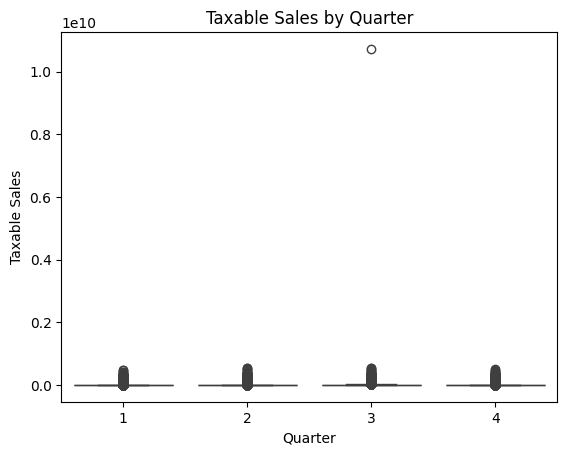

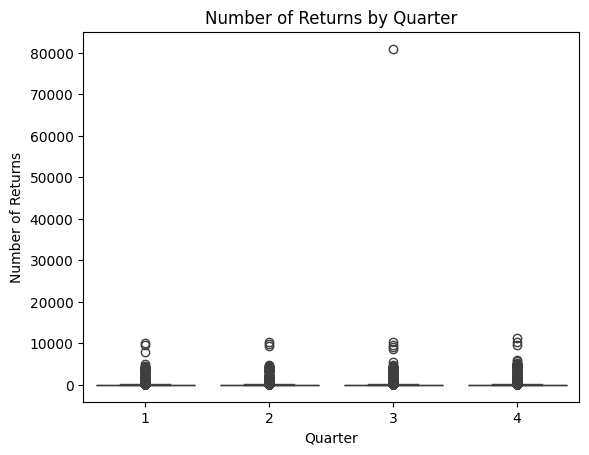

In [84]:
sns.boxplot(x='Quarter', y='Taxable Sales', data=retail_data_cleaned)
plt.title('Taxable Sales by Quarter')
plt.show()

sns.boxplot(x='Quarter', y='Number of Returns', data=retail_data_cleaned)
plt.title('Number of Returns by Quarter')
plt.show()

     Taxable Sales  Number of Returns
Q_1         -0.016             -0.012
Q_2          0.003             -0.010
Q_3          0.010              0.000
Q_4          0.003              0.021


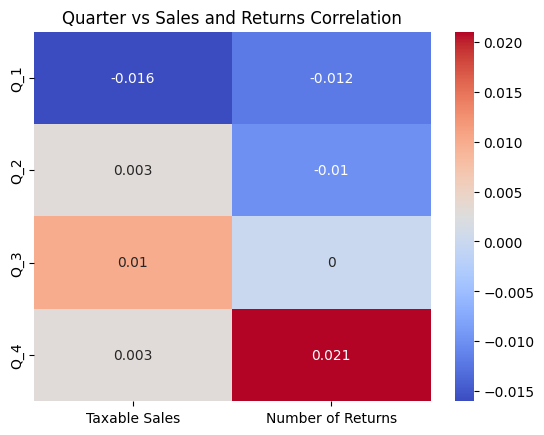

In [85]:
# create quarter dummies
quarter_dummies = pd.get_dummies(retail_data_cleaned['Quarter'], prefix='Q')

# combine with variables of interest
df_corr = pd.concat([
    quarter_dummies,
    retail_data_cleaned[['Taxable Sales', 'Number of Returns']]
], axis=1)

# correlation matrix
corr = df_corr.corr().loc[
    ['Q_1', 'Q_2', 'Q_3', 'Q_4'],
    ['Taxable Sales', 'Number of Returns']
].round(3)

print(corr)

# heatmap
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Quarter vs Sales and Returns Correlation')
plt.show()

Its also now interesting to see if there is a different behavior for sales/ returns withing different business groups

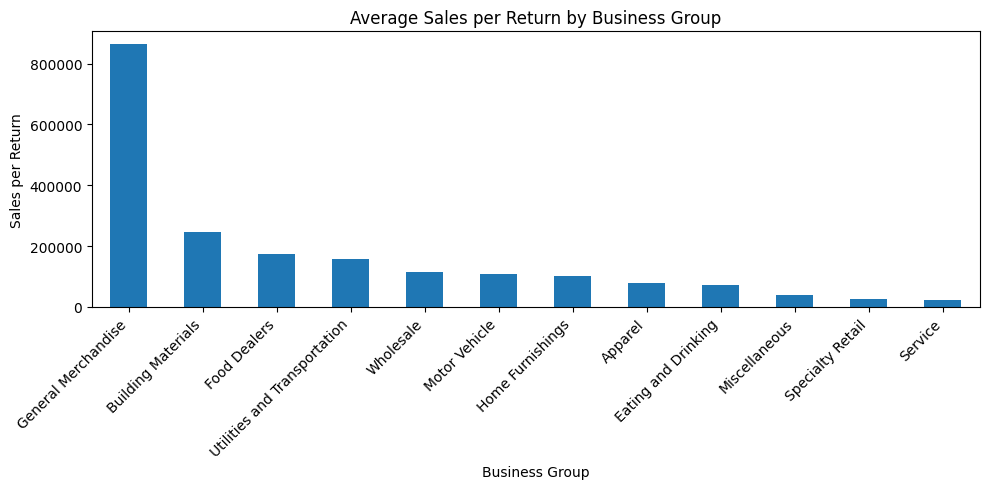

In [86]:
# create sales per return metric
retail_data_cleaned['sales_per_return'] = (
    retail_data_cleaned['Taxable Sales'] / retail_data_cleaned['Number of Returns']
)

# aggregate by business group
sales_per_return = retail_data_cleaned.groupby('Business Group')['sales_per_return'].mean().sort_values(ascending=False)

# plot
sales_per_return.plot.bar(figsize=(10,5))

plt.title('Average Sales per Return by Business Group')
plt.xlabel('Business Group')
plt.ylabel('Sales per Return')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Sales over time
# Shows the retail growth of IOWA 

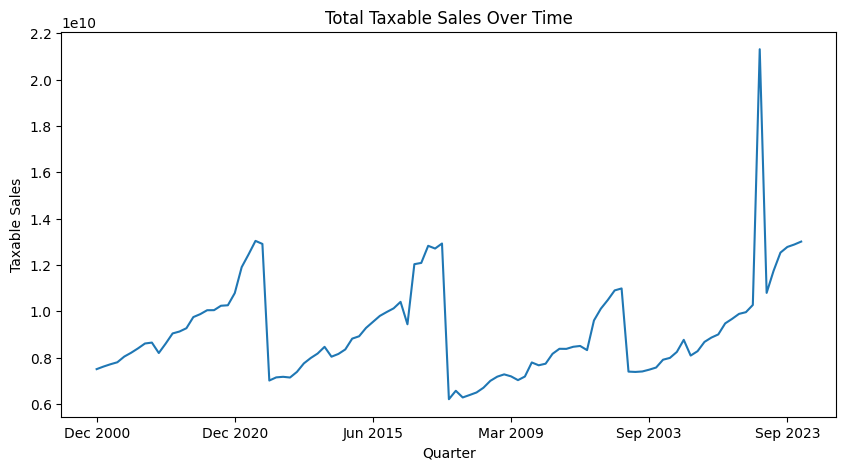

In [87]:
# aggregate sales by time
sales_time = retail_data_cleaned.groupby('Quarter Ending')['Taxable Sales'].sum().sort_index()

# plot
sales_time.plot(figsize=(10,5))
plt.title('Total Taxable Sales Over Time')
plt.xlabel('Quarter')
plt.ylabel('Taxable Sales')
plt.show()

Makes sense, because Q1 is the slowest in sales in retail/ sales in general. Interesting that Q1 is not as highly corrleated with returns as Q4, since you would think people return christmas/ new year gifts. Increases visually coincide with Q4 as well here.

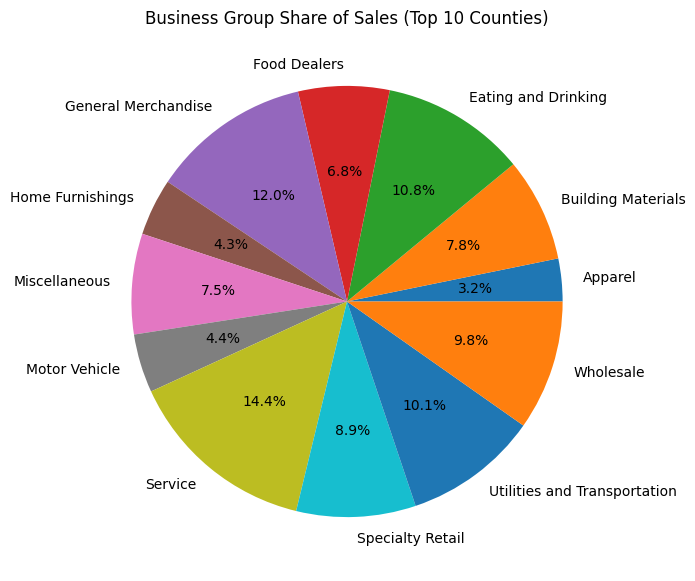

In [88]:
# top 10 counties by total sales
top_counties = retail_data_cleaned.groupby('County')['Taxable Sales'].sum().nlargest(10).index

# filter data
subset = retail_data_cleaned[retail_data_cleaned['County'].isin(top_counties)]

# aggregate by business group
grouped = subset.groupby('Business Group')['Taxable Sales'].sum()

# pie chart
grouped.plot.pie(figsize=(7,7), autopct='%1.1f%%')
plt.title('Business Group Share of Sales (Top 10 Counties)')
plt.ylabel('')
plt.show()

Interesting to see the spread here. Data above is for TOp 10 counties by spend.  

## Now I will look at the share of different Business Groups across time
Stacked graph makes sense here. We see 2008 financial crisis here, and what is probably the 2020 covid pandemic

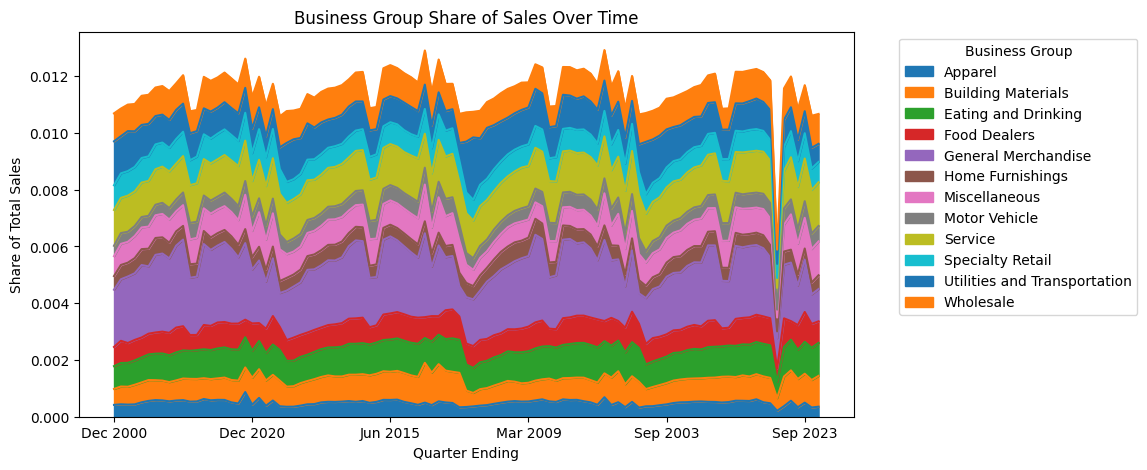

In [89]:
import matplotlib.pyplot as plt

total = retail_data_cleaned.groupby('Quarter Ending')['Taxable Sales'].sum()

share = retail_data_cleaned.copy()
share['share'] = share['Taxable Sales'] / share.groupby('Quarter Ending')['Taxable Sales'].transform('sum')

pivot_share = share.pivot_table(
    values='share',
    index='Quarter Ending',
    columns='Business Group',
    aggfunc='mean'
)

pivot_share.plot.area(figsize=(10,5))

plt.title('Business Group Share of Sales Over Time')
plt.xlabel('Quarter Ending')
plt.ylabel('Share of Total Sales')
plt.legend(title='Business Group', bbox_to_anchor=(1.05, 1))
plt.show()

Now I will look at the distribution of each Business Group / industry across Counties

Below we see we have 100 unique counties. We will see the share 

In [90]:
retail_data_cleaned['County'].unique()

<StringArray>
[       'Hardin',        'Howard',        'Keokuk',          'Tama',
       'Kossuth',      'Harrison',         'Henry',         'Adair',
         'Cedar',         'Boone',        'Marion',           'Sac',
        'Warren',     'Chickasaw',           'Lee',          'Page',
        'Taylor',        'Clarke',          'Clay',        'Monona',
       'Madison',           'Ida',      'Humboldt',        'Shelby',
     'Winnebago',    'Winneshiek',       'Hancock',    'Washington',
       'Jackson',        'Jasper',       'Clinton',         'Adams',
     'Allamakee',     'Appanoose',       'Audubon',        'Benton',
    'Black Hawk',        'Bremer',      'Buchanan',   'Buena Vista',
        'Butler',       'Calhoun',       'Carroll',          'Cass',
   'Cerro Gordo',      'Cherokee',       'Clayton',      'Crawford',
        'Dallas',         'Davis',       'Decatur',      'Delaware',
    'Des Moines',     'Dickinson',       'Dubuque',         'Emmet',
       'Fayette',   

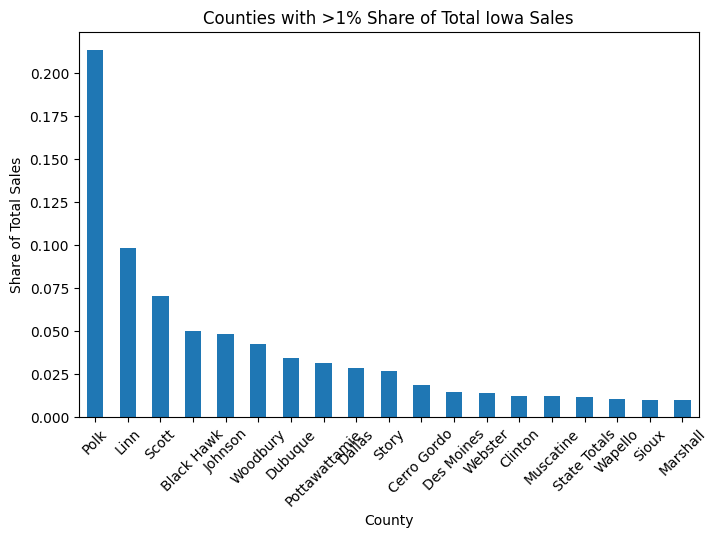

In [91]:
# total sales by county
county_sales = retail_data_cleaned.groupby('County')['Taxable Sales'].sum()

# compute share of total Iowa sales
total_sales = county_sales.sum()
county_share = county_sales / total_sales

# filter counties with >1% share
top_counties = county_share[county_share > 0.01].sort_values(ascending=False)

# contribution of these counties
top_counties

top_counties.plot.bar(figsize=(8,5))
plt.title('Counties with >1% Share of Total Iowa Sales')
plt.ylabel('Share of Total Sales')
plt.xlabel('County')
plt.xticks(rotation=45)
plt.show()



In [98]:
# total computed tax by county (sorted descending)
tax_by_county = retail_data_cleaned.groupby('County')['Computed Tax'].sum().sort_values(ascending=False)

tax_by_county

County
Polk          1.147993e+10
Linn          5.291474e+09
Scott         3.781378e+09
Black Hawk    2.684683e+09
Johnson       2.587875e+09
                  ...     
Louisa        4.689190e+07
Audubon       4.495209e+07
Wayne         4.361174e+07
Adams         3.872634e+07
Taylor        3.643636e+07
Name: Computed Tax, Length: 100, dtype: float64

By sorting by total sales and total tax contibution the numbers don't change. 

we now move on to investingating more among the business groups
## Sales By Business Group

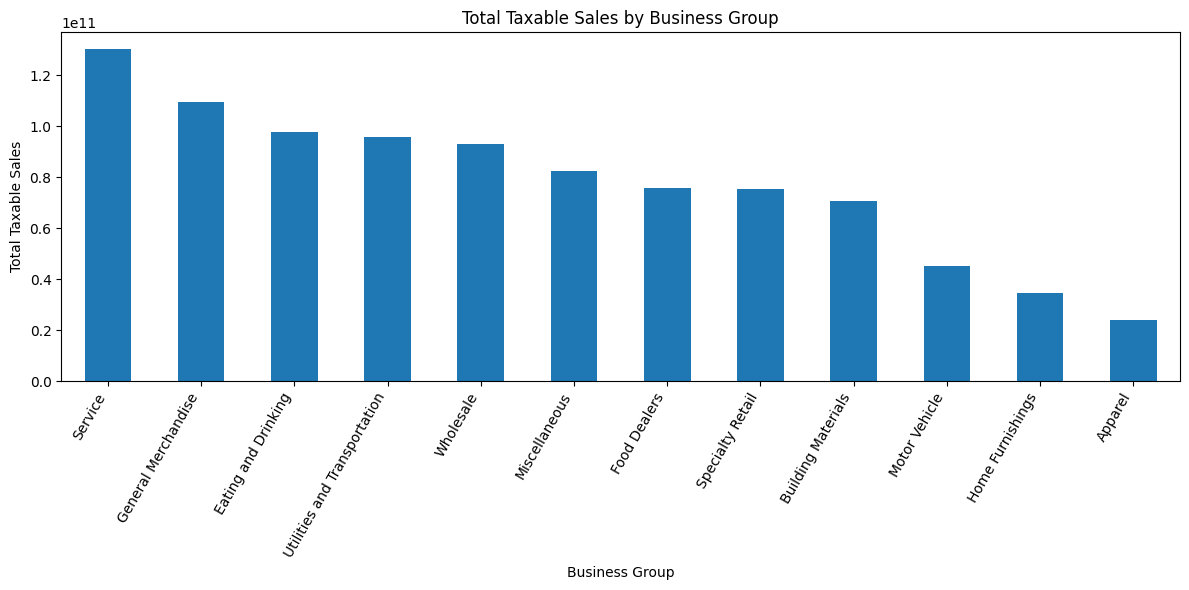

In [92]:
business_sales = retail_data_cleaned.groupby('Business Group')['Taxable Sales'].sum().sort_values(ascending=False)

ax = business_sales.plot.bar(figsize=(12,6))

plt.title('Total Taxable Sales by Business Group')
plt.xlabel('Business Group')
plt.ylabel('Total Taxable Sales')

plt.xticks(rotation=60, ha='right')  # rotate + align
plt.tight_layout()  # prevents cutoff

plt.show()

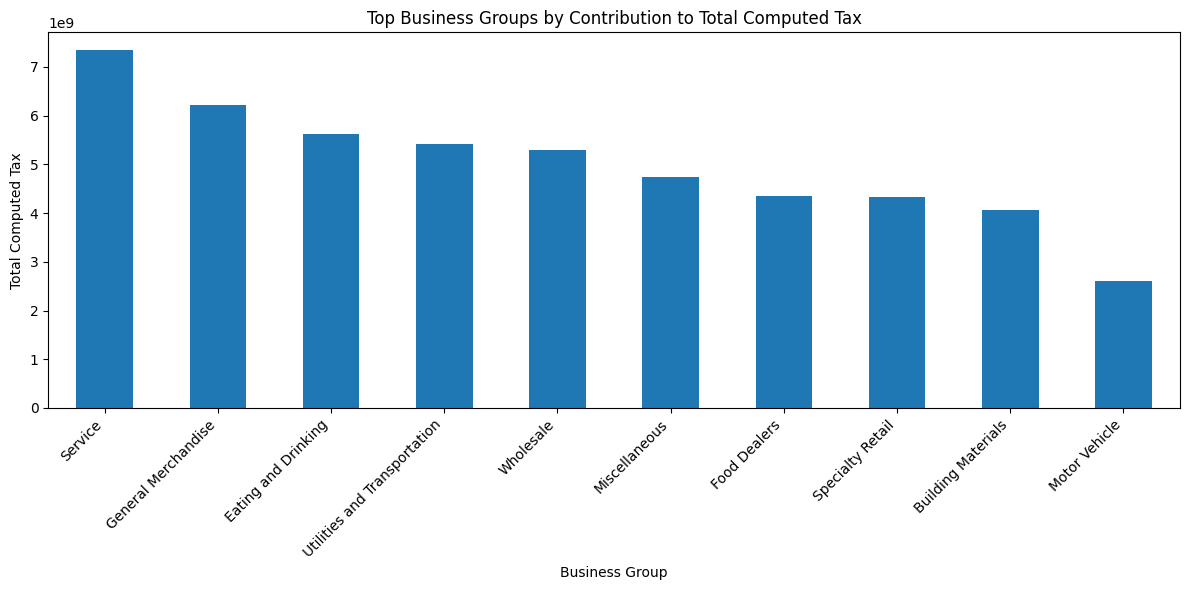

In [97]:
# total computed tax by business group
tax_by_group = retail_data_cleaned.groupby('Business Group')['Computed Tax'].sum().sort_values(ascending=False)

# plot top contributors
tax_by_group.head(10).plot.bar(figsize=(12,6))

plt.title('Top Business Groups by Contribution to Total Computed Tax')
plt.xlabel('Business Group')
plt.ylabel('Total Computed Tax')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Interesting that Service is the biggest contributor of sales/ tax.  No surprise the order is the same.

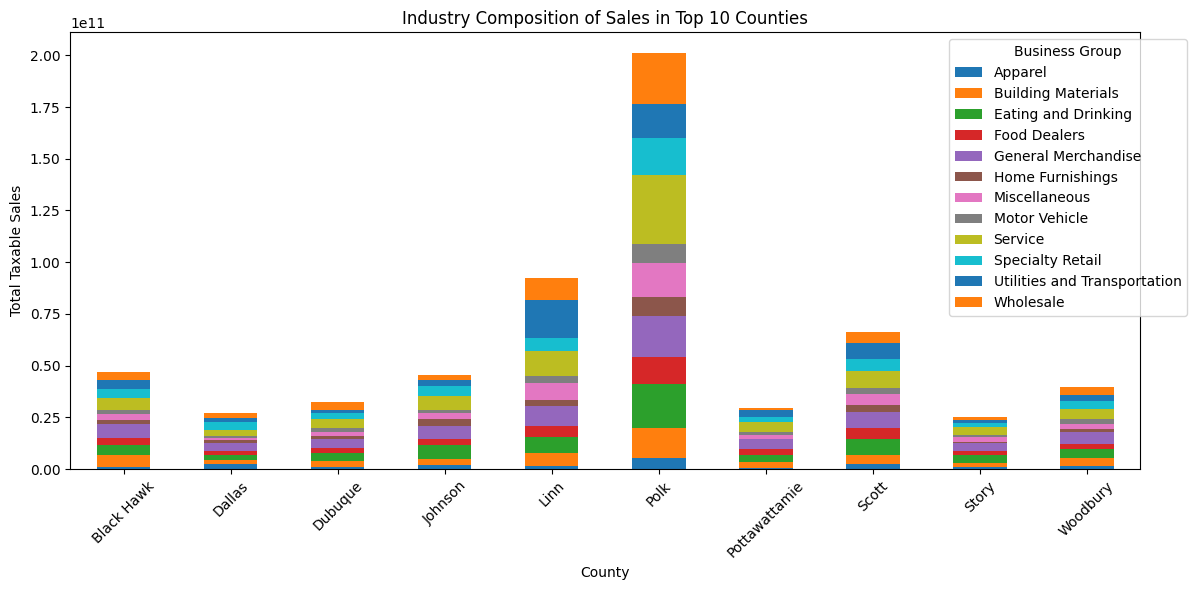

In [96]:
top_counties = retail_data_cleaned.groupby('County')['Taxable Sales'].sum().nlargest(10).index

subset = retail_data_cleaned[retail_data_cleaned['County'].isin(top_counties)]

pivot = subset.pivot_table(
    values='Taxable Sales',
    index='County',
    columns='Business Group',
    aggfunc='sum'
)

pivot.plot(kind='bar', stacked=True, figsize=(12,6))

plt.title('Industry Composition of Sales in Top 10 Counties')
plt.xlabel('County')
plt.ylabel('Total Taxable Sales')
plt.xticks(rotation=45)
plt.legend(title='Business Group', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

Seems like Pol is great at service and Building materials, and overall all other categories compared to the other counties. 

## IOWA SALES GROWTH OVER TIME

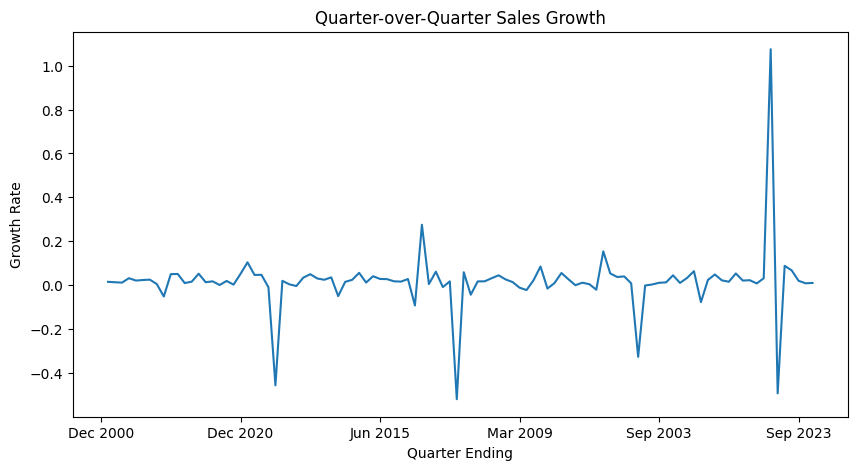

In [94]:
sales_time = retail_data_cleaned.groupby('Quarter Ending')['Taxable Sales'].sum().sort_index()

growth = sales_time.pct_change()

growth.plot(figsize=(10,5))
plt.title('Quarter-over-Quarter Sales Growth')
plt.xlabel('Quarter Ending')
plt.ylabel('Growth Rate')
plt.show()

## Insights
This analysis primarily uses sales as a metric of economic growth in the retail sector. By using sales we clearly see drops in 2008 and during the 2020+ pandemic. 

Taxable sales are highly skewed, with a small number of counties and business groups contributing a large share of total economic activity. This indicates a strong concentration of retail performance in specific regions and sectors, which we saw by looking at %share of county contritbutions and the business groups.

There is a clear correlation between taxable sales and computed tax, which is logical  as expected, and a moderate relationship between sales and the number of returns. This suggests that transaction volume is an important driver of total sales.

Third, analysis across time shows overall stability with some variation, while quarterly differences do not appear to be a strong standalone predictor of sales.

During the data cleaning process, important issues were identified. The dataset included suppressed values and aggregated rows such as “County Totals” and “State Totals,” which could lead to double counting. These were removed to ensure accurate analysis. Additionally, missing values and formatting inconsistencies (currency symbols and percentages) were addressed.

Overall, the dataset provides a clear view of how retail activity is distributed across industries and counties in IOWA.